In [3]:
from google.colab import files
uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [4]:
import pandas as pd

df = pd.read_csv('sales_data.csv')

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [6]:
print(df.shape)

(1000, 14)


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [7]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [8]:
vendas_por_categoria = df.groupby('Product_Category')['Quantity_Sold'].sum().sort_values(ascending=False)
print(vendas_por_categoria)

Product_Category
Clothing       6922
Furniture      6729
Electronics    6096
Food           5608
Name: Quantity_Sold, dtype: int64


In [9]:
receita_por_categoria = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)
print(receita_por_categoria)

Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Sales_Amount, dtype: float64


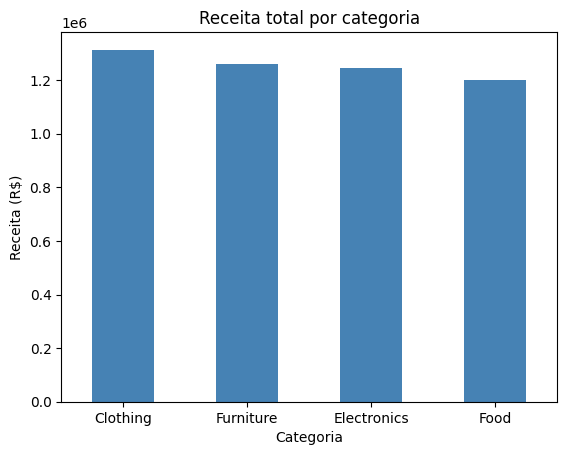

In [10]:
import matplotlib.pyplot as plt

receita_por_categoria = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)

receita_por_categoria.plot(kind='bar', color='steelblue')
plt.title('Receita total por categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.show()

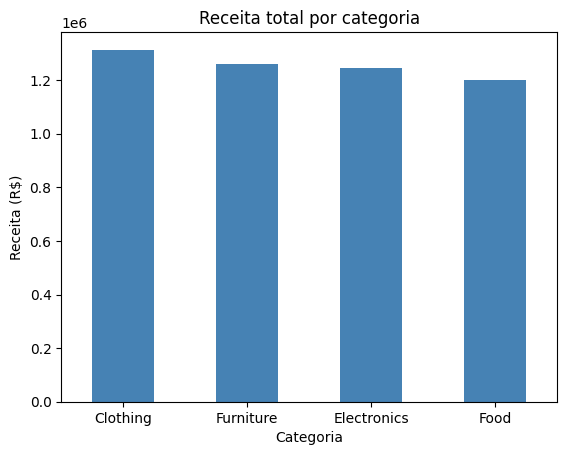

In [11]:
import matplotlib.pyplot as plt

receita_por_categoria = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)

receita_por_categoria.plot(kind='bar', color='steelblue')
plt.title('Receita total por categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.show()

In [13]:
# receita total por vendedor
receita_por_vendedor = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False)
print(receita_por_vendedor)

# quantidade vendida por vendedor
qtd_por_vendedor = df.groupby('Sales_Rep')['Quantity_Sold'].sum().sort_values(ascending=False)
print(qtd_por_vendedor)

# numero de transacoes (vendas) por vendedor
transacoes_por_vendedor = df['Sales_Rep'].value_counts()
print(transacoes_por_vendedor)

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Sales_Amount, dtype: float64
Sales_Rep
David      6042
Eve        5287
Bob        4977
Alice      4832
Charlie    4217
Name: Quantity_Sold, dtype: int64
Sales_Rep
David      222
Eve        209
Bob        208
Alice      192
Charlie    169
Name: count, dtype: int64


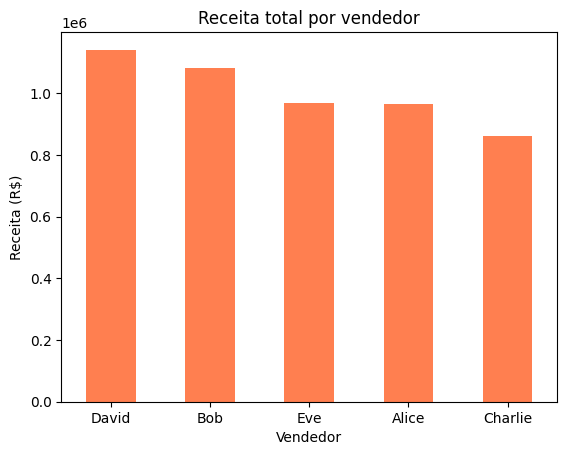

In [14]:
receita_por_vendedor.plot(kind='bar', color='coral')
plt.title('Receita total por vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.show()

Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64


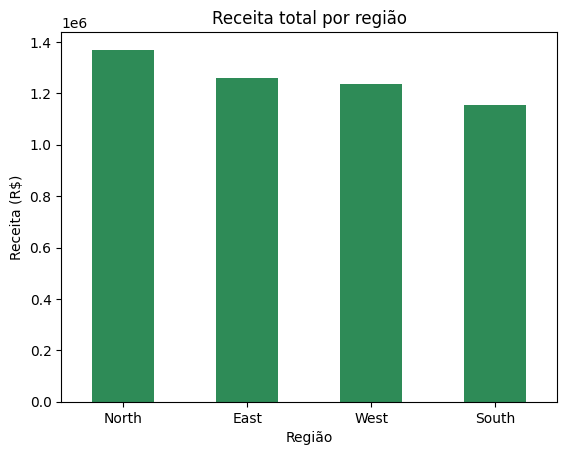

In [15]:
receita_por_regiao = df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False)
print(receita_por_regiao)

receita_por_regiao.plot(kind='bar', color='seagreen')
plt.title('Receita total por região')
plt.xlabel('Região')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.show()

In [16]:
ticket_medio_vendedor = df.groupby('Sales_Rep')['Sales_Amount'].mean().sort_values(ascending=False)
print(ticket_medio_vendedor)

Sales_Rep
Bob        5197.070337
David      5142.961081
Charlie    5093.559053
Alice      5028.863385
Eve        4642.028660
Name: Sales_Amount, dtype: float64


Correlação Desconto x Quantidade vendida: -0.008
Faixa_Desconto
0-10%     26.227545
10-20%    24.517799
20-30%    25.378299
Name: Quantity_Sold, dtype: float64


/tmp/ipykernel_5425/2113918313.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_por_faixa = df.groupby('Faixa_Desconto')['Quantity_Sold'].mean()


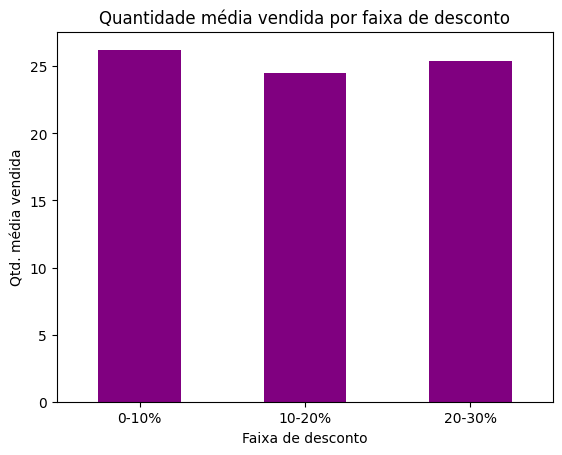

In [18]:
correlacao = df['Discount'].corr(df['Quantity_Sold'])
print(f'Correlação Desconto x Quantidade vendida: {correlacao:.3f}')

df['Faixa_Desconto'] = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3], labels=['0-10%', '10-20%', '20-30%'])
media_por_faixa = df.groupby('Faixa_Desconto')['Quantity_Sold'].mean()
print(media_por_faixa)

media_por_faixa.plot(kind='bar', color='purple')
plt.title('Quantidade média vendida por faixa de desconto')
plt.xlabel('Faixa de desconto')
plt.ylabel('Qtd. média vendida')
plt.xticks(rotation=0)
plt.show()

## Conclusões da Análise

Este projeto analisou 1.000 registros de vendas, cobrindo categorias de produto,
vendedores, regiões e políticas de desconto, com o objetivo de identificar padrões
relevantes para o negócio.

**Principais achados:**

1. **Categoria de produto**: *Clothing* foi a categoria líder tanto em volume
   (6.922 unidades) quanto em receita (R\$ 1.313.474,36), seguida por Furniture,
   Electronics e Food.

2. **Desempenho por vendedor**: *David* teve a maior receita total (R\$ 1.141.737,36)
   e o maior número de vendas (222 transações). Porém, ao analisar o **ticket médio**
   (receita média por venda), *Bob* liderou com R\$ 5.197,07 — mostrando que ele fecha
   vendas de maior valor, mesmo vendendo com menos frequência que David.

3. **Desempenho por região**: a região *North* concentrou a maior receita
   (R\$ 1.369.612,51), à frente de East, West e South.

4. **Impacto do desconto nas vendas**: a correlação entre desconto e quantidade
   vendida foi praticamente nula (-0,008), e a quantidade média vendida se manteve
   estável entre as faixas de 0-10%, 10-20% e 20-30% de desconto. Isso sugere que,
   neste conjunto de dados, **descontos maiores não geraram aumento de volume de vendas**,
   podendo indicar perda de margem sem retorno proporcional.

**Recomendação de negócio:** revisar a política de descontos, já que ela não parece
influenciar o volume de vendas nesta base — o esforço promocional talvez traga mais
retorno se direcionado a ações de marketing ou expansão de vendedores com maior
ticket médio, como o padrão observado em Bob.

**Ferramentas utilizadas:** Python, pandas (manipulação e agregação de dados),
matplotlib (visualização de dados).